In [1]:
from eregion.tasks import ImageCreator, AssembleFocalPlane
from eregion.tasks.custom import guess_image_type_from_filename_DEIMOS, load_image_fits_DEIMOS
from eregion.tasks.calibration import MasterBias, CalibrationResult
from eregion.tasks.preprocessing import BiasSubtraction, ScanSubtraction, SigmaClipMasking

import numpy as np
import os
import glob2
import importlib

# Example: DEIMOS science focal plane characterization: PTC

In [2]:
basepath = '/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI'
runid = '20260718*'
rawpath = glob2.glob(os.path.join(basepath, runid))[0]
outpath = rawpath.replace('/DTU_dettest/','/DTU_detreduce/')
if not os.path.exists(outpath):
    os.makedirs(outpath)

### Calproc

In [3]:
# Load bias images
creator = ImageCreator(detector_config = '../src/eregion/configs/detectors/deimos_sci.yaml')
res = creator.run(input_source = os.path.join(rawpath,'*bias*.fits'),
                  identifier_func = guess_image_type_from_filename_DEIMOS,
                  fileloader_func = load_image_fits_DEIMOS,
                  data_on_demand = True)

# subtract overscan
oscan_sub = ScanSubtraction(which_scan='serial_overscan', method='median_by_axis')
res = oscan_sub.run(images=res.data('type == "bias"'))

# make master bias
master_bias_task = MasterBias(method='median')
mb_res = master_bias_task.run(images=res.data('type == "bias"'))


2026-08-21 15:01:38,775 - DetectorConfig - INFO - Config loaded from file '../src/eregion/configs/detectors/deimos_sci.yaml'
2026-08-21 15:01:38,775 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718-001407/*bias*.fits is a glob pattern
2026-08-21 15:01:46,776 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout o

In [4]:
# cleanup memory
del res
# save master bias result obj
mb_res.save(outpath)

In [3]:
# load master bias result obj
mb_res = CalibrationResult.load(outpath)
mb_res.master_bias

,type,exptime,obstime,seqnum,led,backbias,serial_overscan_subtracted,det_id,filename,object
0,master_bias,0.0,2026-07-18T001412.976,0,GREEN,-50.0,True,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
1,master_bias,0.0,2026-07-18T001412.976,0,GREEN,-50.0,True,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
2,master_bias,0.0,2026-07-18T001412.976,0,GREEN,-50.0,True,det_3,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
3,master_bias,0.0,2026-07-18T001412.976,0,GREEN,-50.0,True,det_4,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
4,master_bias,0.0,2026-07-18T001412.976,0,GREEN,-50.0,True,det_5,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
5,master_bias,0.0,2026-07-18T001412.976,0,GREEN,-50.0,True,det_6,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
6,master_bias,0.0,2026-07-18T001412.976,0,GREEN,-50.0,True,det_7,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
7,master_bias,0.0,2026-07-18T001412.976,0,GREEN,-50.0,True,det_8,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...


Make focal plane image. `AssembleFocalPlane` task can take ImageBundle and group them into sets of focal plane images based on the list of columns that uniquely identify an exposure.

In [4]:
def plot_focal_plane(bundle, grouping_columns=['type', 'exptime', 'seqnum'], how_many=1, zscale=False, with_mask=False, **imshow_kwargs):
    fp_task = AssembleFocalPlane(num_detectors=8)
    fp_res = fp_task.run(from_images=bundle, groupby_keys=grouping_columns)
    for i in range(how_many):
        img = fp_res.data[i]
        if zscale:
            vmin, vmax = np.percentile(img.data.values, [5, 95])
        else:
            vmin, vmax = None, None
        img.show(cmap='gray', show_det_id=True, with_mask=with_mask, vmin=vmin, vmax=vmax, **imshow_kwargs)
    return fp_res.data

,object,filename,type,exptime,obstime,seqnum,led,backbias,serial_overscan_subtracted
0,<eregion.datamodels.focalplaneimage.FocalPlane...,None,master_bias,0.0,2026-07-18T001412.976,0,GREEN,-50.0,True


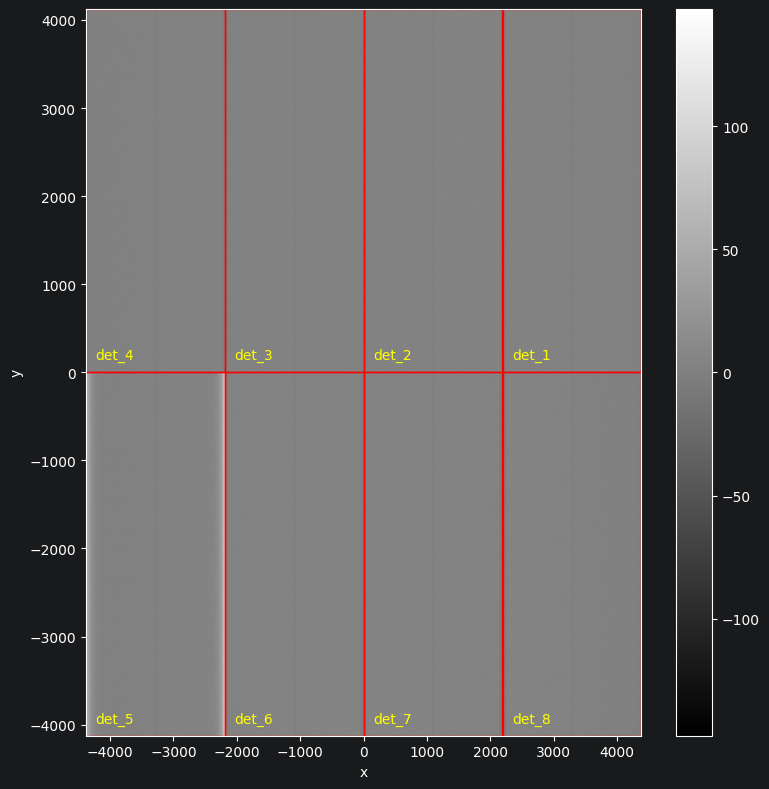

In [7]:
plot_focal_plane(mb_res.master_bias)

### Preproc

Sanity checks for each step

In [5]:
def quick_plot(img):
    vmin, vmax = np.percentile(img.data.values, [5, 95])
    img.show(cmap='gray', vmin=vmin, vmax=vmax, origin='lower')

2026-08-21 15:15:09,791 - eregion.datamodels.image - WARNING - Mask key 'sigma_clip_mask' not found in DetImage masks. Showing unmasked data.


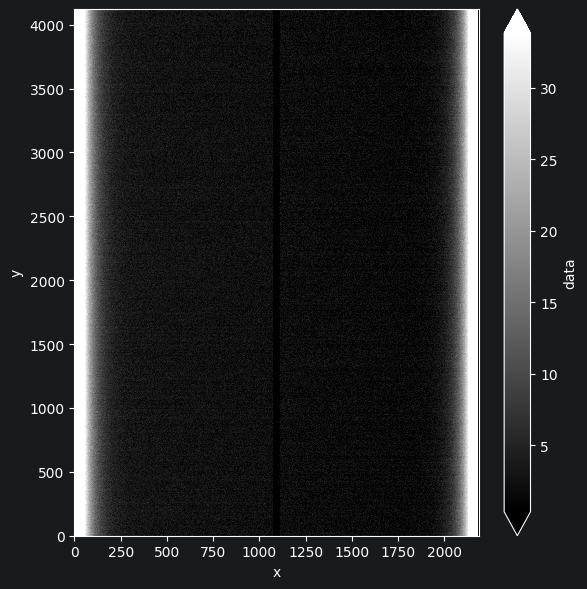

In [6]:
# plot master bias
quick_plot(mb_res.master_bias[4])

In [7]:
## Loading a pair at an exptime
creator = ImageCreator(detector_config='../src/eregion/configs/detectors/deimos_sci.yaml', max_batch_size=2)

flpair = creator.run(input_source='/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*SCI_*_flat_0.032*.fits',
                  identifier_func=guess_image_type_from_filename_DEIMOS,
                  fileloader_func=load_image_fits_DEIMOS,
                  data_on_demand=True)
flpair.data

2026-08-21 15:15:12,489 - DetectorConfig - INFO - Config loaded from file '../src/eregion/configs/detectors/deimos_sci.yaml'
2026-08-21 15:15:12,489 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*SCI_*_flat_0.032*.fits is a glob pattern


,type,exptime,obstime,seqnum,led,backbias,det_id,filename,object
0,flat,0.032,2026-07-18T040300.129,0,GREEN,-50.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
1,flat,0.032,2026-07-18T040427.627,1,GREEN,-50.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
2,flat,0.032,2026-07-18T040300.129,0,GREEN,-50.0,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
3,flat,0.032,2026-07-18T040427.627,1,GREEN,-50.0,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
4,flat,0.032,2026-07-18T040300.129,0,GREEN,-50.0,det_3,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
5,flat,0.032,2026-07-18T040427.627,1,GREEN,-50.0,det_3,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
6,flat,0.032,2026-07-18T040300.129,0,GREEN,-50.0,det_4,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
7,flat,0.032,2026-07-18T040427.627,1,GREEN,-50.0,det_4,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
8,flat,0.032,2026-07-18T040300.129,0,GREEN,-50.0,det_5,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
9,flat,0.032,2026-07-18T040427.627,1,GREEN,-50.0,det_5,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...


,object,filename,type,exptime,obstime,seqnum,led,backbias
0,<eregion.datamodels.focalplaneimage.FocalPlane...,None,flat,0.032,2026-07-18T040300.129,0,GREEN,-50.0
1,<eregion.datamodels.focalplaneimage.FocalPlane...,None,flat,0.032,2026-07-18T040427.627,1,GREEN,-50.0


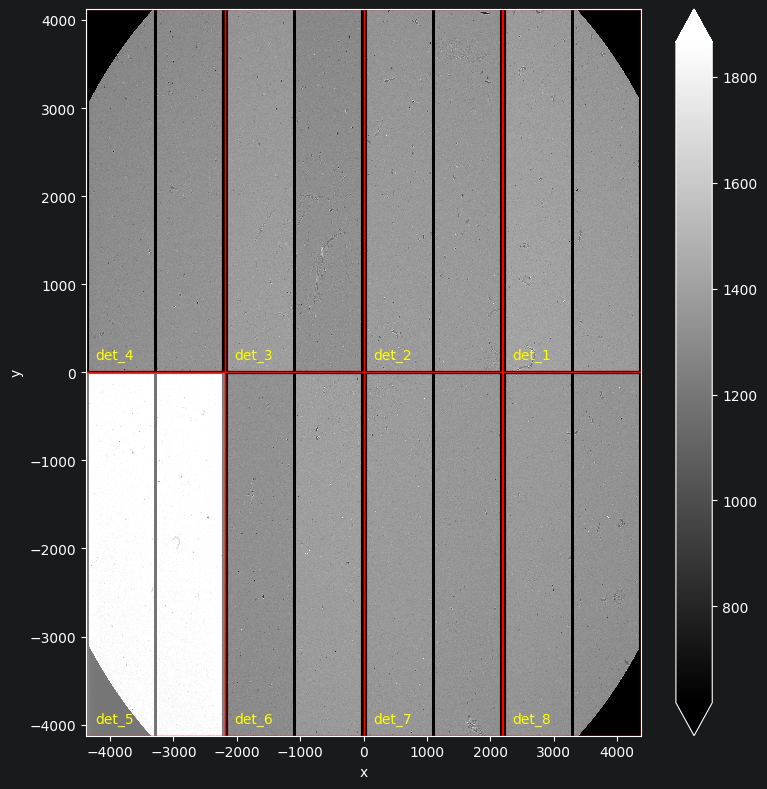

In [11]:
# quick_plot(flpair.data[0])
plot_focal_plane(flpair.data, zscale=True)

In [8]:
# Do overscan sub
oscan_sub = ScanSubtraction(which_scan='serial_overscan', method='median_by_axis')
flpair = oscan_sub.run(images=flpair.data)

2026-08-21 15:15:16,271 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,object,filename,type,exptime,obstime,seqnum,led,backbias,serial_overscan_subtracted
0,<eregion.datamodels.focalplaneimage.FocalPlane...,None,flat,0.032,2026-07-18T040300.129,0,GREEN,-50.0,True
1,<eregion.datamodels.focalplaneimage.FocalPlane...,None,flat,0.032,2026-07-18T040427.627,1,GREEN,-50.0,True


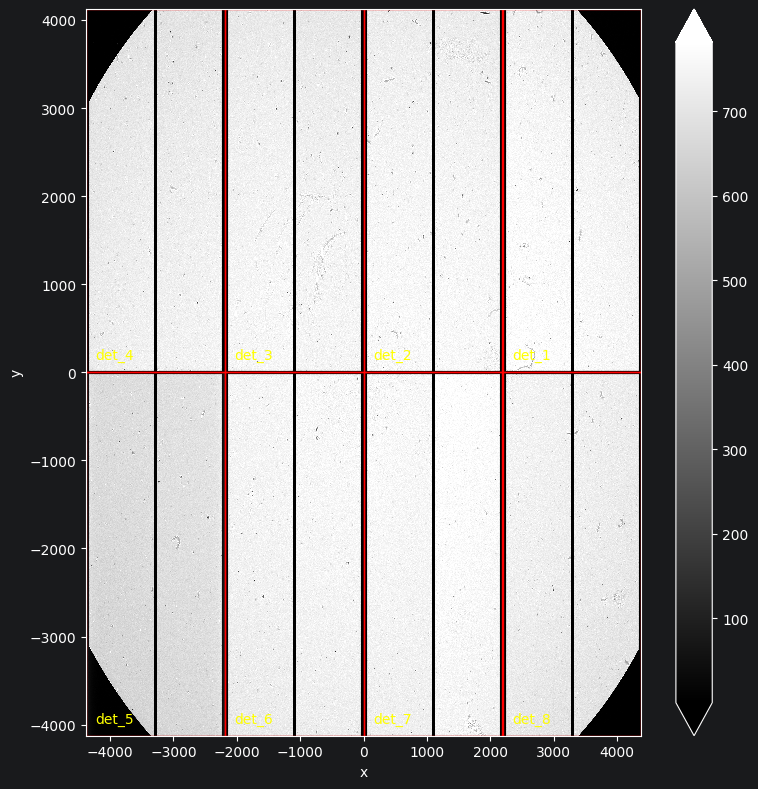

In [13]:
# quick_plot(after_osub.data[0])
plot_focal_plane(flpair.data, zscale=True)

In [9]:
# Do sigma clip
cr_mask = SigmaClipMasking(sigma_clip_args={'sigma_lower':5, 'sigma_upper':5}) # set n_jobs=1 to be able to debug in pycharm inside parallelized jobs
flpair = cr_mask.run(images=flpair.data)

2026-08-21 15:15:21,305 - sigma_clip_masking - INFO - Setting method 'ccd' for task sigma_clip_masking.
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak

,object,filename,type,exptime,obstime,seqnum,led,backbias,serial_overscan_subtracted,bad_pixel_masked
0,<eregion.datamodels.focalplaneimage.FocalPlane...,None,flat,0.032,2026-07-18T040300.129,0,GREEN,-50.0,True,True
1,<eregion.datamodels.focalplaneimage.FocalPlane...,None,flat,0.032,2026-07-18T040427.627,1,GREEN,-50.0,True,True


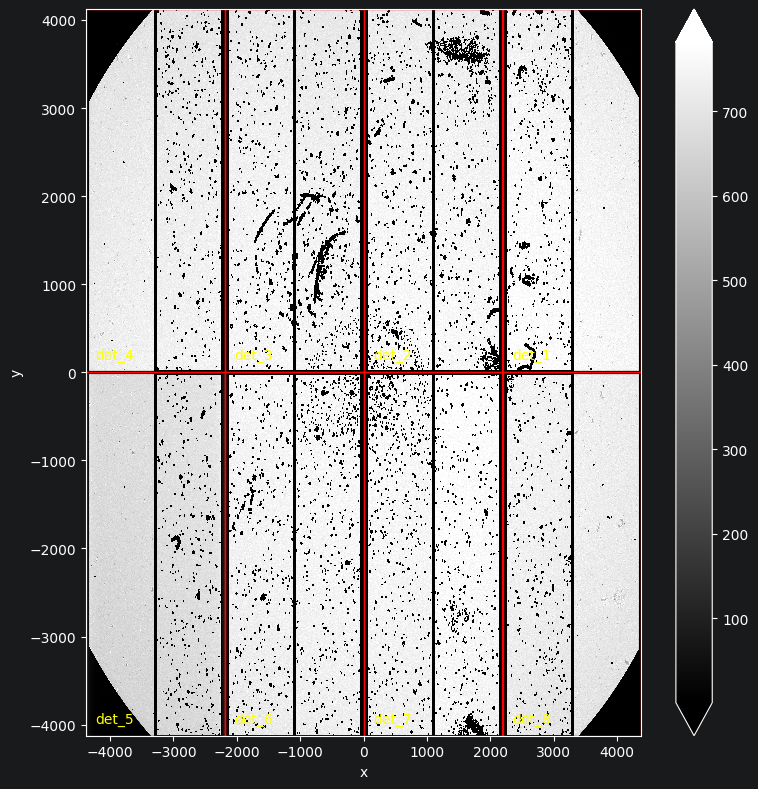

In [10]:
plot_focal_plane(flpair.data, zscale=True, with_mask=True)

In [11]:
# Do bias sub
bias_sub = BiasSubtraction(only_image_area=True)
flpair = bias_sub.run(images=flpair.data, master_bias=mb_res.master_bias)

/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,object,filename,type,exptime,obstime,seqnum,led,backbias,serial_overscan_subtracted,bad_pixel_masked,bias_subtracted
0,<eregion.datamodels.focalplaneimage.FocalPlane...,None,flat,0.032,2026-07-18T040300.129,0,GREEN,-50.0,True,True,True
1,<eregion.datamodels.focalplaneimage.FocalPlane...,None,flat,0.032,2026-07-18T040427.627,1,GREEN,-50.0,True,True,True


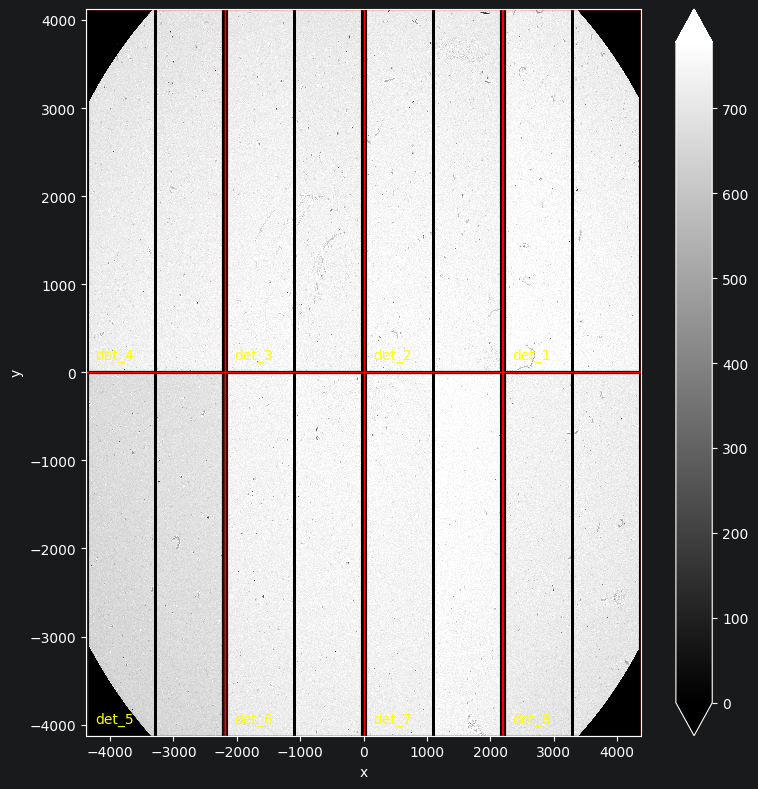

In [12]:
# quick_plot(after_bs.data[0])
plot_focal_plane(flpair.data, zscale=True)

In [32]:
# Do PTC
import eregion.tasks.ptc as ptc
import eregion
importlib.reload(eregion)
importlib.reload(ptc)

ptc_task = ptc.PTC()
pres = ptc_task.run(images=flpair.data)

0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.01s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

In [33]:
pres.ptc_table

,exptime,det_id,output,n_masked_0,mean_0,median_0,std_0,mad_0,skew_0,kurt_0,...,lastllel_median_0-1,lastllel_std_0-1,lastllel_mad_0-1,lastser_mean_0-1,lastser_median_0-1,lastser_std_0-1,lastser_mad_0-1,mean,median,std
0,0.032,det_1,E,1848,661.162878,738.734177,231.079295,28.066792,-2.460592,4.197910,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,661.181314,738.736992,15.712093
1,0.032,det_1,F,363812,755.735827,756.358479,24.711469,24.580365,-0.103593,0.125224,...,NaN,NaN,NaN,0.014830,0.125492,23.703787,23.809395,755.742521,756.353592,16.987887
2,0.032,det_2,E,485747,742.796730,743.348984,23.289477,22.949963,-0.124876,0.233537,...,1.482147,15.662826,16.899111,-0.059379,-0.486938,22.708570,22.515505,742.791888,743.339123,16.317807
3,0.032,det_2,F,371940,744.028228,744.300499,23.012686,22.923139,-0.038620,0.124552,...,0.827217,15.458184,14.761265,NaN,NaN,NaN,NaN,744.039537,744.311909,16.355293
4,0.032,det_3,E,482533,731.921758,731.996841,23.527912,23.328883,0.023247,0.223987,...,0.000885,14.681994,14.833352,-0.290170,-0.073524,22.165524,22.102731,731.941740,732.016434,15.935002
5,0.032,det_3,F,319383,736.383414,736.736687,22.970828,22.858545,-0.045198,0.148527,...,-0.977341,15.359831,15.864382,-0.219652,-0.390743,22.371528,21.778378,736.400599,736.751085,15.870564
6,0.032,det_4,E,275427,722.330401,722.950531,23.176734,23.188554,-0.108072,0.090600,...,-0.373657,14.980296,15.283295,-0.068636,-0.158943,22.416379,22.394525,722.340593,722.957687,15.865113
7,0.032,det_4,F,2823,633.085236,712.703728,229.389683,26.081513,-2.358281,3.678646,...,0.551224,15.054473,14.354893,NaN,NaN,NaN,NaN,633.052639,712.704016,14.506787
8,0.032,det_5,E,1421,591.233164,660.577225,206.882140,23.395914,-2.465646,4.203745,...,0.218056,14.759150,14.488865,NaN,NaN,NaN,NaN,591.210076,660.578632,14.007926
9,0.032,det_5,F,276840,677.147221,677.419296,19.595682,19.499999,-0.064501,0.108892,...,0.568626,14.181562,15.029276,0.368057,0.663666,20.434851,20.517592,677.142439,677.413616,14.531655


In [34]:
# save to fits
pres.save(outpath)

In [35]:
# load from fits
pres = ptc.PTCResult.load(outpath)
pres.ptc_table

,exptime,det_id,output,n_masked_0,mean_0,median_0,std_0,mad_0,skew_0,kurt_0,...,lastllel_median_0-1,lastllel_std_0-1,lastllel_mad_0-1,lastser_mean_0-1,lastser_median_0-1,lastser_std_0-1,lastser_mad_0-1,mean,median,std
0,0.032,det_1,E,1848,661.162878,738.734177,231.079295,28.066792,-2.460592,4.197910,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,661.181314,738.736992,15.712093
1,0.032,det_1,F,363812,755.735827,756.358479,24.711469,24.580365,-0.103593,0.125224,...,NaN,NaN,NaN,0.014830,0.125492,23.703787,23.809395,755.742521,756.353592,16.987887
2,0.032,det_2,E,485747,742.796730,743.348984,23.289477,22.949963,-0.124876,0.233537,...,1.482147,15.662826,16.899111,-0.059379,-0.486938,22.708570,22.515505,742.791888,743.339123,16.317807
3,0.032,det_2,F,371940,744.028228,744.300499,23.012686,22.923139,-0.038620,0.124552,...,0.827217,15.458184,14.761265,NaN,NaN,NaN,NaN,744.039537,744.311909,16.355293
4,0.032,det_3,E,482533,731.921758,731.996841,23.527912,23.328883,0.023247,0.223987,...,0.000885,14.681994,14.833352,-0.290170,-0.073524,22.165524,22.102731,731.941740,732.016434,15.935002
5,0.032,det_3,F,319383,736.383414,736.736687,22.970828,22.858545,-0.045198,0.148527,...,-0.977341,15.359831,15.864382,-0.219652,-0.390743,22.371528,21.778378,736.400599,736.751085,15.870564
6,0.032,det_4,E,275427,722.330401,722.950531,23.176734,23.188554,-0.108072,0.090600,...,-0.373657,14.980296,15.283295,-0.068636,-0.158943,22.416379,22.394525,722.340593,722.957687,15.865113
7,0.032,det_4,F,2823,633.085236,712.703728,229.389683,26.081513,-2.358281,3.678646,...,0.551224,15.054473,14.354893,NaN,NaN,NaN,NaN,633.052639,712.704016,14.506787
8,0.032,det_5,E,1421,591.233164,660.577225,206.882140,23.395914,-2.465646,4.203745,...,0.218056,14.759150,14.488865,NaN,NaN,NaN,NaN,591.210076,660.578632,14.007926
9,0.032,det_5,F,276840,677.147221,677.419296,19.595682,19.499999,-0.064501,0.108892,...,0.568626,14.181562,15.029276,0.368057,0.663666,20.434851,20.517592,677.142439,677.413616,14.531655


For everything together, check out deimos_sci_testing.py